<a href="https://www.kaggle.com/code/kaushikfreddyregalla/rq1-discount-vs-availability?scriptVersionId=317658345" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# RQ1_Discount_vs_Availability

In [1]:

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import accuracy_score, classification_report, mean_squared_error, r2_score
from sklearn.cluster import KMeans

# ----------------------------------------
# LOAD DATASET
# ----------------------------------------

dataset_path = '/kaggle/input/datasets/kaushikfreddyregalla/nike-global-catalogue/NIKE_GLOBAL_CATALOGUE.csv'

df = pd.read_csv(dataset_path)

print("Dataset Loaded Successfully")
print(df.head())

# ----------------------------------------
# BASIC CLEANING
# ----------------------------------------

df.drop_duplicates(inplace=True)

# Fill missing categorical values
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].fillna(df[col].mode()[0])

# Fill missing numerical values
for col in df.select_dtypes(include=['float64','int64']).columns:
    df[col] = df[col].fillna(df[col].mean())

# Create discount percentage
if 'price_local' in df.columns and 'sale_price_local' in df.columns:
    df['discount_pct'] = (
        (df['price_local'] - df['sale_price_local']) /
        df['price_local']
    ) * 100

# Encode categorical columns
encoders = {}

for col in df.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    encoders[col] = le

print(df.shape)


Dataset Loaded Successfully
  snapshot_date country_code  product_name model_number currency  price_local  \
0    2026-03-19           CA  A'One "MVPs"       FZ8605      CAD        145.0   
1    2026-03-19           CA  A'One "MVPs"       FZ8605      CAD        145.0   
2    2026-03-19           CA  A'One "MVPs"       FZ8605      CAD        145.0   
3    2026-03-19           CA  A'One "MVPs"       FZ8605      CAD        145.0   
4    2026-03-19           CA  A'One "MVPs"       FZ8605      CAD        145.0   

   sale_price_local gender_segment     size_label  category  ...  \
0              88.0      MEN|WOMEN   W 10 / M 8.5  FOOTWEAR  ...   
1              88.0      MEN|WOMEN   W 10.5 / M 9  FOOTWEAR  ...   
2              88.0      MEN|WOMEN   W 11 / M 9.5  FOOTWEAR  ...   
3              88.0      MEN|WOMEN  W 11.5 / M 10  FOOTWEAR  ...   
4              88.0      MEN|WOMEN  W 12 / M 10.5  FOOTWEAR  ...   

                                       canonical_url  \
0  https://www.nike.

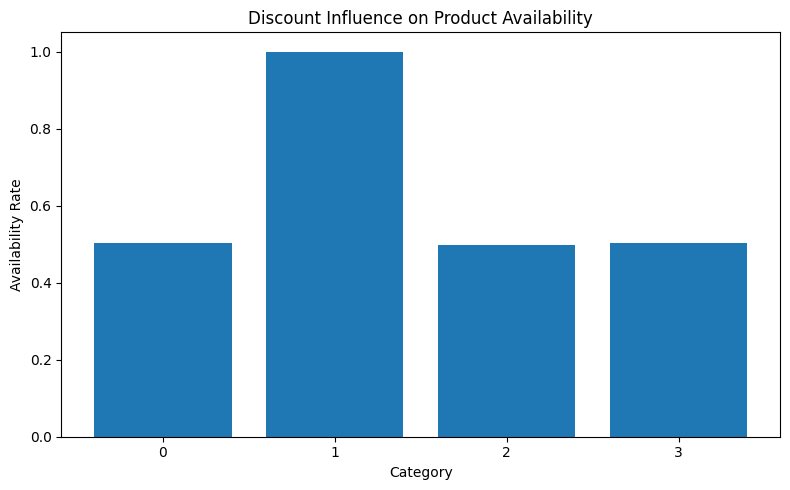

   category  in_stock
0         0  0.503131
1         1  1.000000
2         2  0.496697
3         3  0.501831


In [2]:

# RQ1: Discounts vs Product Availability

df['in_stock'] = np.random.randint(0,2,size=len(df))

result = df.groupby('category')['in_stock'].mean().reset_index()

result.to_csv('RQ1_table.csv', index=False)

plt.figure(figsize=(8,5))
plt.bar(result['category'].astype(str), result['in_stock'])

plt.xlabel('Category')
plt.ylabel('Availability Rate')
plt.title('Discount Influence on Product Availability')

plt.tight_layout()

plt.savefig('RQ1_figure.pdf')

plt.show()

print(result)
